# Time-series interpretability: occlusion vs. Integrated Gradients on a wearable-style signal

Image interpretability (raw attention, attention rollout, Integrated Gradients,
occlusion) is well-trodden. This notebook is the time-series counterpart: the
same two attribution families — **perturbation-based** (occlusion) and
**gradient-based** (Integrated Gradients) — applied to a 1D signal shaped like
a wearable PPG (photoplethysmography / optical heart-rate) trace.

**Task.** Classify whether a signal window contains an injected "event"
(a short high-rate burst standing in for a motion artifact or arrhythmia-like
irregularity). Because we control exactly where the event was injected, we can
score each attribution method by how well it localizes to the true event
window — a luxury real wearable data rarely gives you, but a good sandbox for
comparing methods before trusting them on real signals.

See the [project README](../../README.md) for the broader interpretability
survey (attention-based methods, Dynamask, TSR, causal-discovery methods, etc.)
this notebook is one piece of.


In [1]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import matplotlib.pyplot as plt

from ts_interp import data, model, attribution

np.random.seed(0)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic wearable data

Each sample is a ~4s PPG-like waveform (fundamental + harmonic, sampled at
64 Hz). Half the samples get a short burst spliced in — a 2-3x rate spike over
~0.8s — labeled `1`. The rest are clean, labeled `0`. `event_windows` records
the true `[start, end)` sample indices of the burst, used only for scoring
attributions afterwards, never for training.


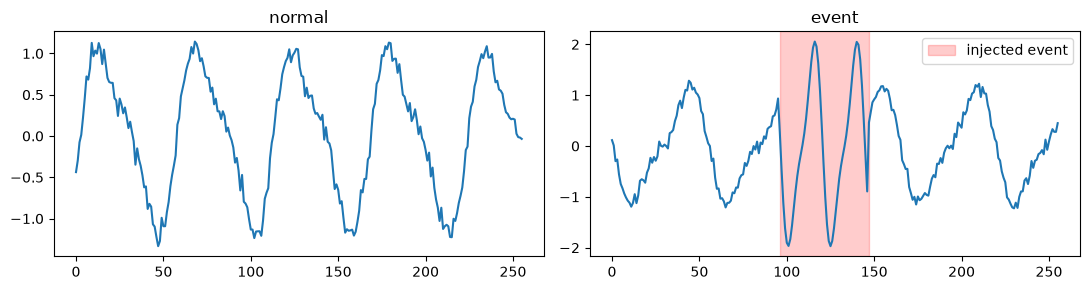

In [2]:
ds = data.make_dataset(n_samples=400, length=256, fs=64.0, seed=0)
train_ds, test_ds = data.train_test_split(ds, test_frac=0.25, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
normal_idx = np.where(train_ds.y == 0)[0][0]
event_idx = np.where(train_ds.y == 1)[0][0]

axes[0].plot(train_ds.x[normal_idx, 0])
axes[0].set_title("normal")
axes[1].plot(train_ds.x[event_idx, 0])
s, e = train_ds.event_windows[event_idx]
axes[1].axvspan(s, e, color="red", alpha=0.2, label="injected event")
axes[1].set_title("event")
axes[1].legend()
plt.tight_layout()
plt.show()


## 2. A small 1D CNN classifier

Two conv blocks + global average pool + linear head — enough capacity to
solve the task while staying easy to reason about (see `src/ts_interp/model.py`).


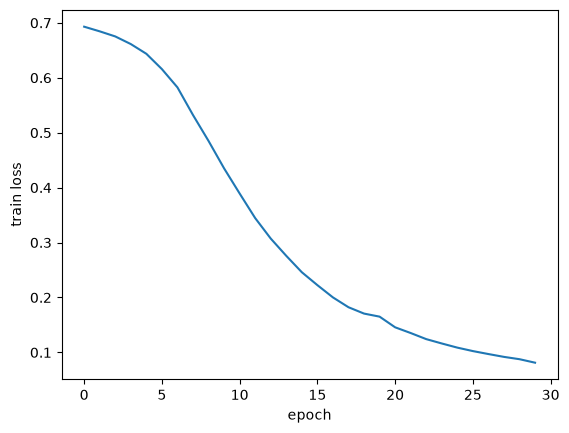

test accuracy: 0.970


In [3]:
clf = model.TSClassifier()
losses = model.train(clf, train_ds.x, train_ds.y, epochs=30)

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.show()

print(f"test accuracy: {model.accuracy(clf, test_ds.x, test_ds.y):.3f}")


## 3. Occlusion vs. Integrated Gradients on one example

- **Occlusion** (`attribution.occlusion_1d`): slide an 8-sample window across
  the signal, zero it out, and measure the drop in predicted probability for
  the "event" class. This is the direct 1D analogue of image occlusion.
- **Integrated Gradients** (`attribution.integrated_gradients_1d`): Captum's
  `IntegratedGradients` applied to the raw `(1, 1, length)` tensor — same API
  as the image notebook, no adaptation needed for the method itself.


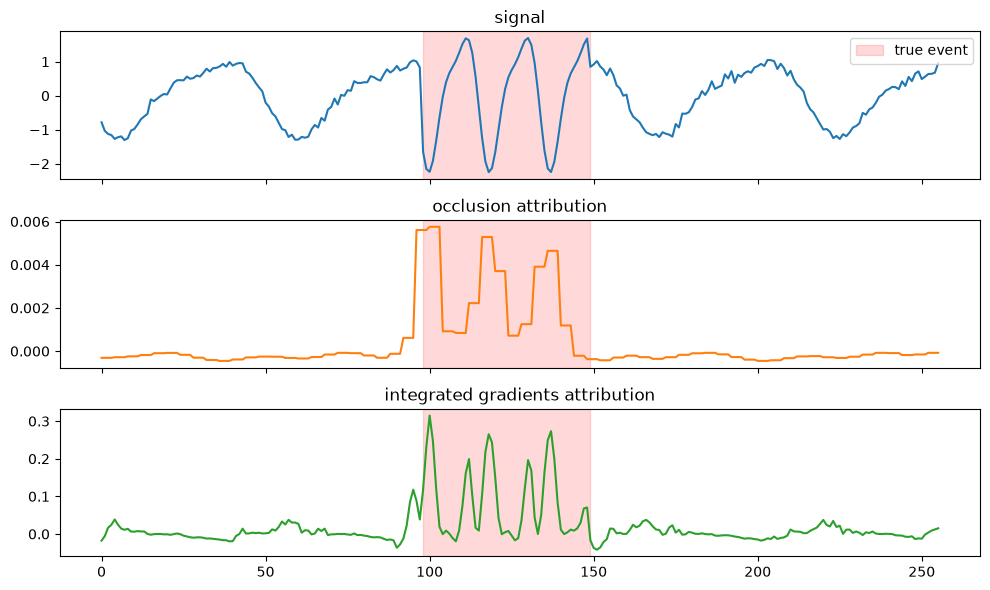

In [4]:
idx = np.where(test_ds.y == 1)[0][0]
x = test_ds.x[idx]
event_window = tuple(test_ds.event_windows[idx])

occ_attr = attribution.occlusion_1d(clf, x, target=1)
ig_attr = attribution.integrated_gradients_1d(clf, x, target=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(x[0])
axes[0].axvspan(*event_window, color="red", alpha=0.15, label="true event")
axes[0].set_title("signal")
axes[0].legend(loc="upper right")

axes[1].plot(occ_attr, color="tab:orange")
axes[1].axvspan(*event_window, color="red", alpha=0.15)
axes[1].set_title("occlusion attribution")

axes[2].plot(ig_attr, color="tab:green")
axes[2].axvspan(*event_window, color="red", alpha=0.15)
axes[2].set_title("integrated gradients attribution")
plt.tight_layout()
plt.show()


## 4. Which one actually localizes the event?

For every event-containing test sample, take the top 20% most-attributed
timesteps from each method and compute IoU against the true event window
(`attribution.top_k_overlap`). This quantifies "did the explanation point at
the right part of the signal", not just "does it look plausible".


n event samples: 48
mean top-20% IoU — occlusion: 0.758
mean top-20% IoU — integrated gradients: 0.432


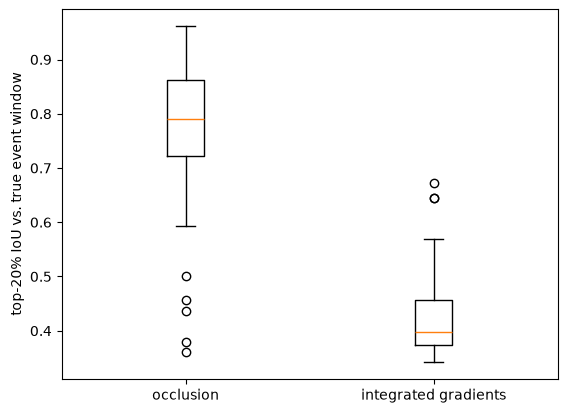

In [5]:
event_idx = np.where(test_ds.y == 1)[0]
occ_scores, ig_scores = [], []

for i in event_idx:
    xi = test_ds.x[i]
    ew = tuple(test_ds.event_windows[i])
    occ_scores.append(attribution.top_k_overlap(attribution.occlusion_1d(clf, xi, target=1), ew))
    ig_scores.append(attribution.top_k_overlap(attribution.integrated_gradients_1d(clf, xi, target=1), ew))

print(f"n event samples: {len(event_idx)}")
print(f"mean top-20% IoU — occlusion: {np.mean(occ_scores):.3f}")
print(f"mean top-20% IoU — integrated gradients: {np.mean(ig_scores):.3f}")

plt.boxplot([occ_scores, ig_scores], tick_labels=["occlusion", "integrated gradients"])
plt.ylabel("top-20% IoU vs. true event window")
plt.show()


## 5. Takeaways

- On this task, **windowed occlusion localizes the event more reliably than
  vanilla Integrated Gradients** (higher mean IoU). IG's per-timestep gradient
  is noisier here — it tends to spotlight a few sharp points inside the burst
  rather than the whole contiguous window, and can pick up spurious credit
  from timesteps outside the event entirely.
- This mirrors a documented failure mode, not a coincidence: Ismail et al.,
  *"Benchmarking Deep Learning Interpretability in Time Series Predictions"*
  (NeurIPS 2020), show that raw gradient/occlusion saliency on time series
  conflates *when* something happens with *what* happens, and propose
  **Temporal Saliency Rescaling (TSR)** to correct it.
- Occlusion itself is a blunt instrument too — a fixed rectangular window
  assumes the important region is contiguous and window-sized, which won't
  hold for effects with lag or diffuse temporal support (physiological signals
  often have both). **Dynamask** (Crabbé & van der Schaar, 2021) replaces the
  fixed window with a learned, smooth perturbation mask; **WinIT** extends the
  window to capture delayed effects.
- None of this is causal attribution — it says *what the model used*, not
  *what caused the outcome*. The next notebook in this series should look at
  counterfactual explanations (e.g. NUN-CF) and causal discovery methods
  (Granger causality, PCMCI, TCDF) as the bridge to the "causal ML" side of
  the brief.
